# Object Detection For Autonomous Driving

## Objective

The goal of this assignment is to fine-tune the YOLO object detection model on a subset of the KITTI dataset, widely used in autonomous driving research. The KITTI dataset provides annotated images for tasks like object detection, tracking, and segmentation, making it ideal for training models to detect objects such as cars, pedestrians, and cyclists.

By completing this assignment, you will gain hands-on experience in dataset preparation, annotation conversion, model training, and performance evaluation using metrics like mAP (mean Average Precision). Additionally, you will explore the trade-offs between speed and accuracy, crucial for real-time applications like autonomous driving.


## Introduction: Object Detection

Object detection is a fundamental task in computer vision that involves identifying and localizing objects within an image or video.

The main techniques for object detection include traditional methods like sliding window and region-based approaches, as well as modern deep learning-based methods such as YOLO (You Only Look Once), SSD (Single Shot MultiBox Detector), and Faster R-CNN. These techniques leverage convolutional neural networks (CNNs) to extract features and predict bounding boxes and class labels for objects in real-time or near real-time.

Widely used models for object detection include:
- **YOLO (You Only Look Once)**: Known for its speed and efficiency in real-time applications.
- **Faster R-CNN**: A two-stage detector that provides high accuracy but is slower compared to single-stage detectors.
- **SSD (Single Shot MultiBox Detector)**: Balances speed and accuracy, making it suitable for various applications.
- **RetinaNet**: Introduces the focal loss to address class imbalance in object detection.
- **EfficientDet**: A family of models that optimize both accuracy and efficiency using compound scaling.

In the context of autonomous vehicles, object detection plays a critical role in perceiving the environment, identifying obstacles, pedestrians, traffic signs, and other vehicles. This capability enables autonomous systems to make informed decisions, ensuring safety and efficiency in navigation and driving scenarios.

## YOLO

YOLO (You Only Look Once) is a state-of-the-art, real-time object detection system. Unlike traditional object detection methods that apply a classifier to different regions of an image, YOLO frames object detection as a single regression problem. It predicts bounding boxes and class probabilities directly from full images in one evaluation, making it extremely fast and efficient.

### Model

The YOLO model divides the input image into a grid, where each grid cell is responsible for predicting bounding boxes and their associated class probabilities. Key features of YOLO include:

- **Unified Architecture**: YOLO uses a single convolutional neural network (CNN) to predict multiple bounding boxes and class probabilities simultaneously.
- **Speed**: YOLO is optimized for real-time applications, capable of processing images at high frame rates.
- **Global Context**: By considering the entire image during training and inference, YOLO reduces false positives and improves detection accuracy.
- **Versions**: Over time, YOLO has evolved through multiple versions (e.g., YOLOv1 up to YOLOv11), each introducing architectural improvements, better loss functions, and enhanced performance.

YOLO is widely used in applications such as autonomous driving, surveillance, and robotics, where real-time object detection is critical.

For more details on YOLO, visit the [Ultralytics GitHub repository](https://github.com/ultralytics/ultralytics).

## Theory Questions


For the next questions, focus on the latest version of the model, YOLOv11

Briefly describe the architecture used in YOLOv11 and the different losses used during training.

ANS: YOLOv11 adopts a one-stage object detection architecture consisting of a backbone for feature extraction, a neck for multi-scale feature fusion, and a detection head that directly predicts bounding boxes, objectness scores, and class probabilities for each spatial location. The training loss in YOLO consists of three components: (1) a bounding box regression loss that measures the localization accuracy (often based on IoU), (2) an objectness loss that indicates whether an object is present in a predicted box, and (3) a classification loss that evaluates the predicted class probabilities.

What are the metrics used to assess YOLO's performance for object detection?

ANS: The performance of YOLO is commonly evaluated using Intersection over Union (IoU) to measure localization accuracy, as well as precision and recall to assess detection quality. The most important metric is mean Average Precision (mAP), which summarizes the precision-recall trade-off across different thresholds and object classes.

## Code

In the next part of the assignment, you will load a YOLO model and fine-tune it on the provided subset of the KITTI dataset.
You will then visualize the training losses and evaluate the model by running inference to assess its performance.

In [ ]:
!pip install ultralytics opencv-python-headless -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.5 MB/s eta 0:00:00


In [ ]:
import os, cv2, glob, random, shutil, requests, zipfile
from ultralytics import YOLO

import matplotlib.pyplot as plt
import pandas as pd
import os

%matplotlib inline

from IPython.display import Image, display
import glob

import yaml
import cv2
import matplotlib.pyplot as plt
import glob

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [5]:
# ---------------------------------------------
# STEP 1: Setup paths
# ---------------------------------------------
HOME = os.getcwd()
DATASET_PATH = os.path.join(HOME, "datasets", "kitti_subset")
IMAGES_PATH = os.path.join(DATASET_PATH, "images")
LABELS_PATH = os.path.join(DATASET_PATH, "labels")

TRAIN_IMG = os.path.join(IMAGES_PATH, "train")
VAL_IMG = os.path.join(IMAGES_PATH, "val")
TEST_IMG = os.path.join(IMAGES_PATH, "test")
TRAIN_LABEL = os.path.join(LABELS_PATH, "train")
VAL_LABEL = os.path.join(LABELS_PATH, "val")
TEST_LABEL = os.path.join(LABELS_PATH, "test")

for path in [TRAIN_IMG, VAL_IMG, TEST_IMG, TRAIN_LABEL, VAL_LABEL, TEST_LABEL]:
    os.makedirs(path, exist_ok=True)

# ---------------------------------------------
# STEP 2: Download and extract KITTI data
# ---------------------------------------------
KITTI_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_image_2.zip"
KITTI_LABELS_URL = "https://s3.eu-central-1.amazonaws.com/avg-kitti/data_object_label_2.zip"

def download_and_extract(url, extract_to):
    zip_path = os.path.join(HOME, url.split("/")[-1])
    if not os.path.exists(zip_path):
        print(f"Downloading {url}...")
        response = requests.get(url, stream=True)
        with open(zip_path, "wb") as file:
            for chunk in response.iter_content(chunk_size=1024):
                if chunk:
                    file.write(chunk)
        print("Download complete.")

    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete.")

download_and_extract(KITTI_URL, IMAGES_PATH)
download_and_extract(KITTI_LABELS_URL, LABELS_PATH)

# ---------------------------------------------
# STEP 3: Convert KITTI annotations to YOLO
# ---------------------------------------------
CLASS_MAP = {"Car": 0, "Pedestrian": 1, "Cyclist": 2}

def convert_kitti_to_yolo(kitti_label_path, yolo_label_path, image_path):
    with open(kitti_label_path, "r") as file:
        lines = file.readlines()

    img = cv2.imread(image_path)
    if img is None:
        return
    height, width, _ = img.shape

    with open(yolo_label_path, "w") as yolo_file:
        for line in lines:
            elements = line.split()
            class_name = elements[0]
            if class_name not in CLASS_MAP:
                continue  # Skip irrelevant classes

            class_id = CLASS_MAP[class_name]
            x1, y1, x2, y2 = map(float, elements[4:8])

            # Convert to YOLO format
            center_x = ((x1 + x2) / 2) / width
            center_y = ((y1 + y2) / 2) / height
            bbox_width = (x2 - x1) / width
            bbox_height = (y2 - y1) / height

            yolo_file.write(f"{class_id} {center_x:.6f} {center_y:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

# ---------------------------------------------
# STEP 4: Prepare dataset (subset, split, convert)
# ---------------------------------------------
all_images = sorted(glob.glob(os.path.join(IMAGES_PATH, "training", "image_2", "*.png")))
all_labels = sorted(glob.glob(os.path.join(LABELS_PATH, "training", "label_2", "*.txt")))

paired_data = list(zip(all_images, all_labels))
random.seed(42)
random.shuffle(paired_data)

# Keep small subset (e.g., 300 images total)
subset_data = paired_data[:300]
train_size = int(0.8 * len(subset_data))
val_size = int(0.1 * len(subset_data))

train_data = subset_data[:train_size]
val_data = subset_data[train_size:train_size + val_size]
test_data = subset_data[train_size + val_size:]

def move_and_convert_files(data, img_dest, lbl_dest):
    for img_path, lbl_path in data:
        new_img_path = os.path.join(img_dest, os.path.basename(img_path))
        new_lbl_path = os.path.join(lbl_dest, os.path.basename(lbl_path))
        shutil.copy2(img_path, new_img_path)
        convert_kitti_to_yolo(lbl_path, new_lbl_path, new_img_path)

move_and_convert_files(train_data, TRAIN_IMG, TRAIN_LABEL)
move_and_convert_files(val_data, VAL_IMG, VAL_LABEL)
move_and_convert_files(test_data, TEST_IMG, TEST_LABEL)


# ---------------------------------------------
# STEP 5: Create data.yaml
# ---------------------------------------------
data_yaml = f"""
path: {DATASET_PATH}
train: images/train
val: images/val
test: images/test

nc: 3
names: ['Car', 'Pedestrian', 'Cyclist']
"""

with open(os.path.join(DATASET_PATH, "data.yaml"), "w") as f:
    f.write(data_yaml)



Extracting /content/data_object_image_2.zip...
Extraction complete.
Download complete.
Extracting /content/data_object_label_2.zip...
Extraction complete.


In [6]:
# ---------------------------------------------
# STEP 6: Fine-tune YOLOv11 model
# ---------------------------------------------
#TO-DO: Add the code to fine-tune the YOLOv11 model
DATA_YAML_PATH = os.path.join(DATASET_PATH, "data.yaml")

model = YOLO("yolo11n.pt")

results = model.train(
    data=DATA_YAML_PATH,
    epochs=20,
    imgsz=640,
    batch=8,
    project=os.path.join(HOME, "runs"),
    name="yolo11_kitti_subset",
    device=0
)

print("Training finished.")
print("Best model should be saved under the runs directory.")

Ultralytics 8.4.36 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/kitti_subset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11_kitti_subset, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

# Inference

After training, visualize the losses andmetrics calculated on the validation set during training.

Additionally, make sure you visualize the confusion matrix to see per-class errors.

For qualitative analysis, run inference on the model, visualise the bouding boxes and visually assess it.

Run directory: /content/runs/yolo11_kitti_subset
Results CSV exists: True
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


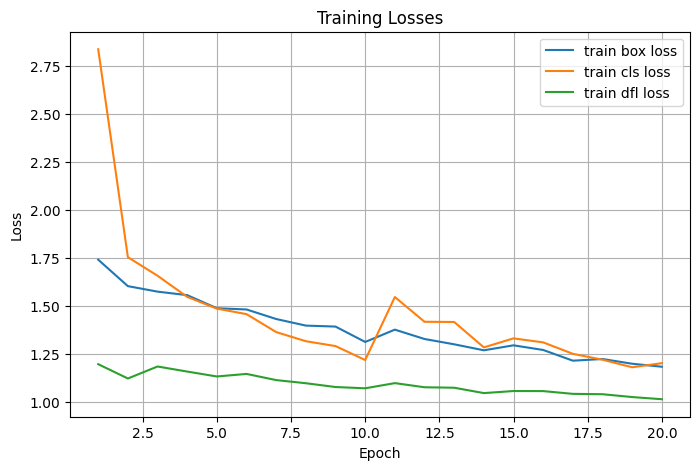

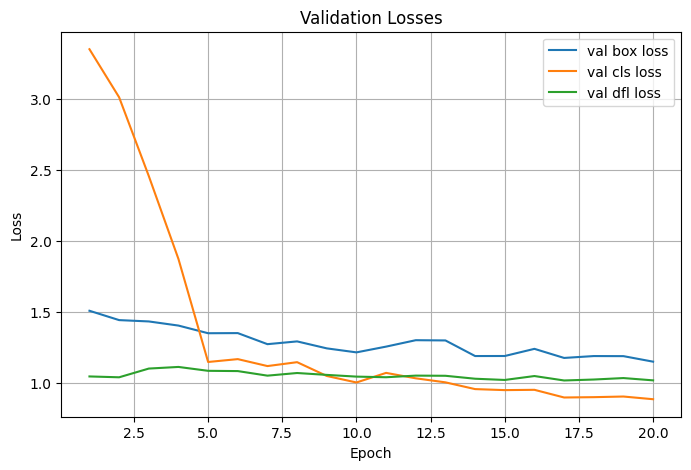

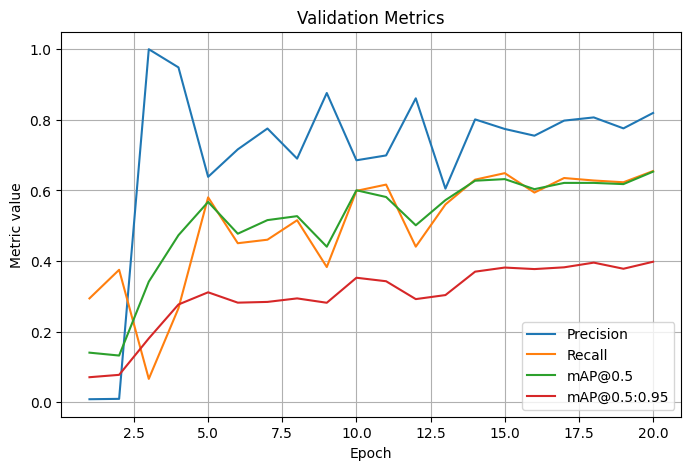

In [8]:
# -------- VISUALIZE TRAINING LOSSES AND METRICS --------
#TO-DO: Add the code to visualize the training losses and metrics

# ---------------------------------------------
# STEP 7: Visualize training losses and metrics
# ---------------------------------------------
# 1) Locate the run directory and CSV file
RUN_DIR = os.path.join(HOME, "runs", "yolo11_kitti_subset")
RESULTS_CSV = os.path.join(RUN_DIR, "results.csv")

print("Run directory:", RUN_DIR)
print("Results CSV exists:", os.path.exists(RESULTS_CSV))

# 2) Load the CSV
results_df = pd.read_csv(RESULTS_CSV)
print(results_df.columns.tolist())


# 3) Plot training losses
plt.figure(figsize=(8, 5))
plt.plot(results_df["epoch"], results_df["train/box_loss"], label="train box loss")
plt.plot(results_df["epoch"], results_df["train/cls_loss"], label="train cls loss")
plt.plot(results_df["epoch"], results_df["train/dfl_loss"], label="train dfl loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid(True)
plt.show()

# 4) Plot validation losses
plt.figure(figsize=(8, 5))
plt.plot(results_df["epoch"], results_df["val/box_loss"], label="val box loss")
plt.plot(results_df["epoch"], results_df["val/cls_loss"], label="val cls loss")
plt.plot(results_df["epoch"], results_df["val/dfl_loss"], label="val dfl loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Losses")
plt.legend()
plt.grid(True)
plt.show()

# 5) Plot validation metrics
plt.figure(figsize=(8, 5))
plt.plot(results_df["epoch"], results_df["metrics/precision(B)"], label="Precision")
plt.plot(results_df["epoch"], results_df["metrics/recall(B)"], label="Recall")
plt.plot(results_df["epoch"], results_df["metrics/mAP50(B)"], label="mAP@0.5")
plt.plot(results_df["epoch"], results_df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95")
plt.xlabel("Epoch")
plt.ylabel("Metric value")
plt.title("Validation Metrics")
plt.legend()
plt.grid(True)
plt.show()

confusion_matrix.png exists: True
confusion_matrix_normalized.png exists: True
Displaying confusion_matrix.png


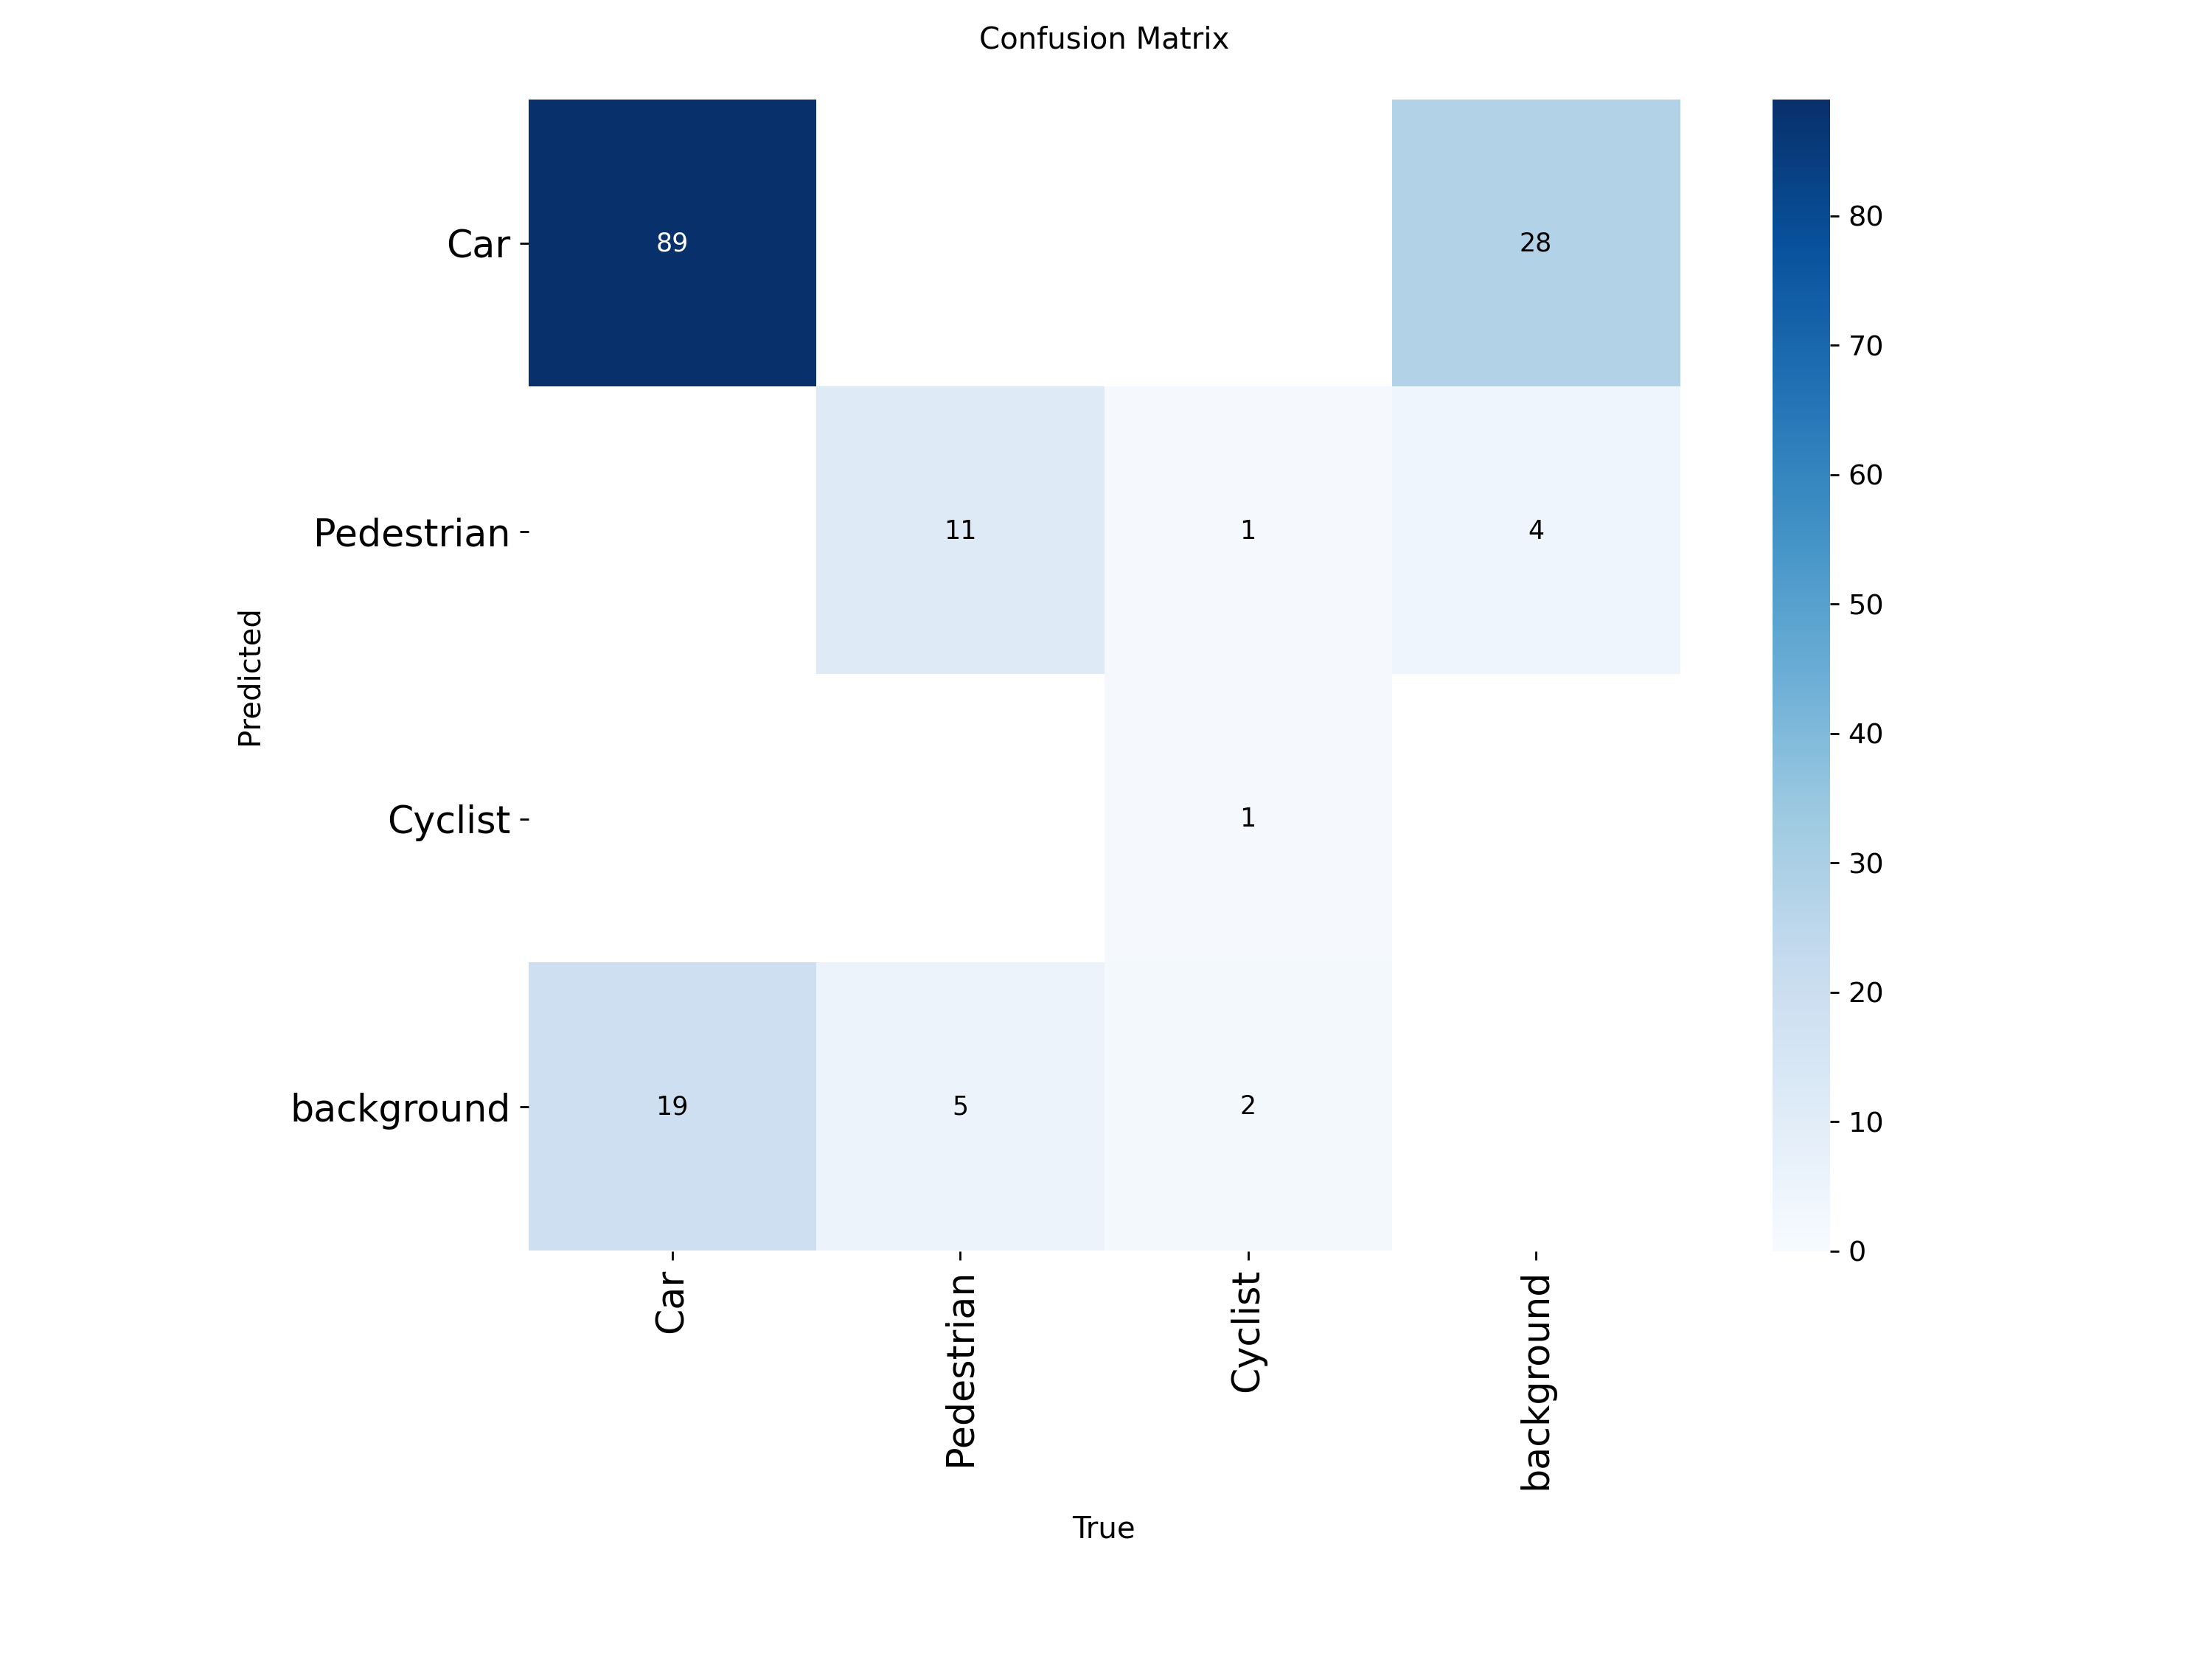

Displaying confusion_matrix_normalized.png


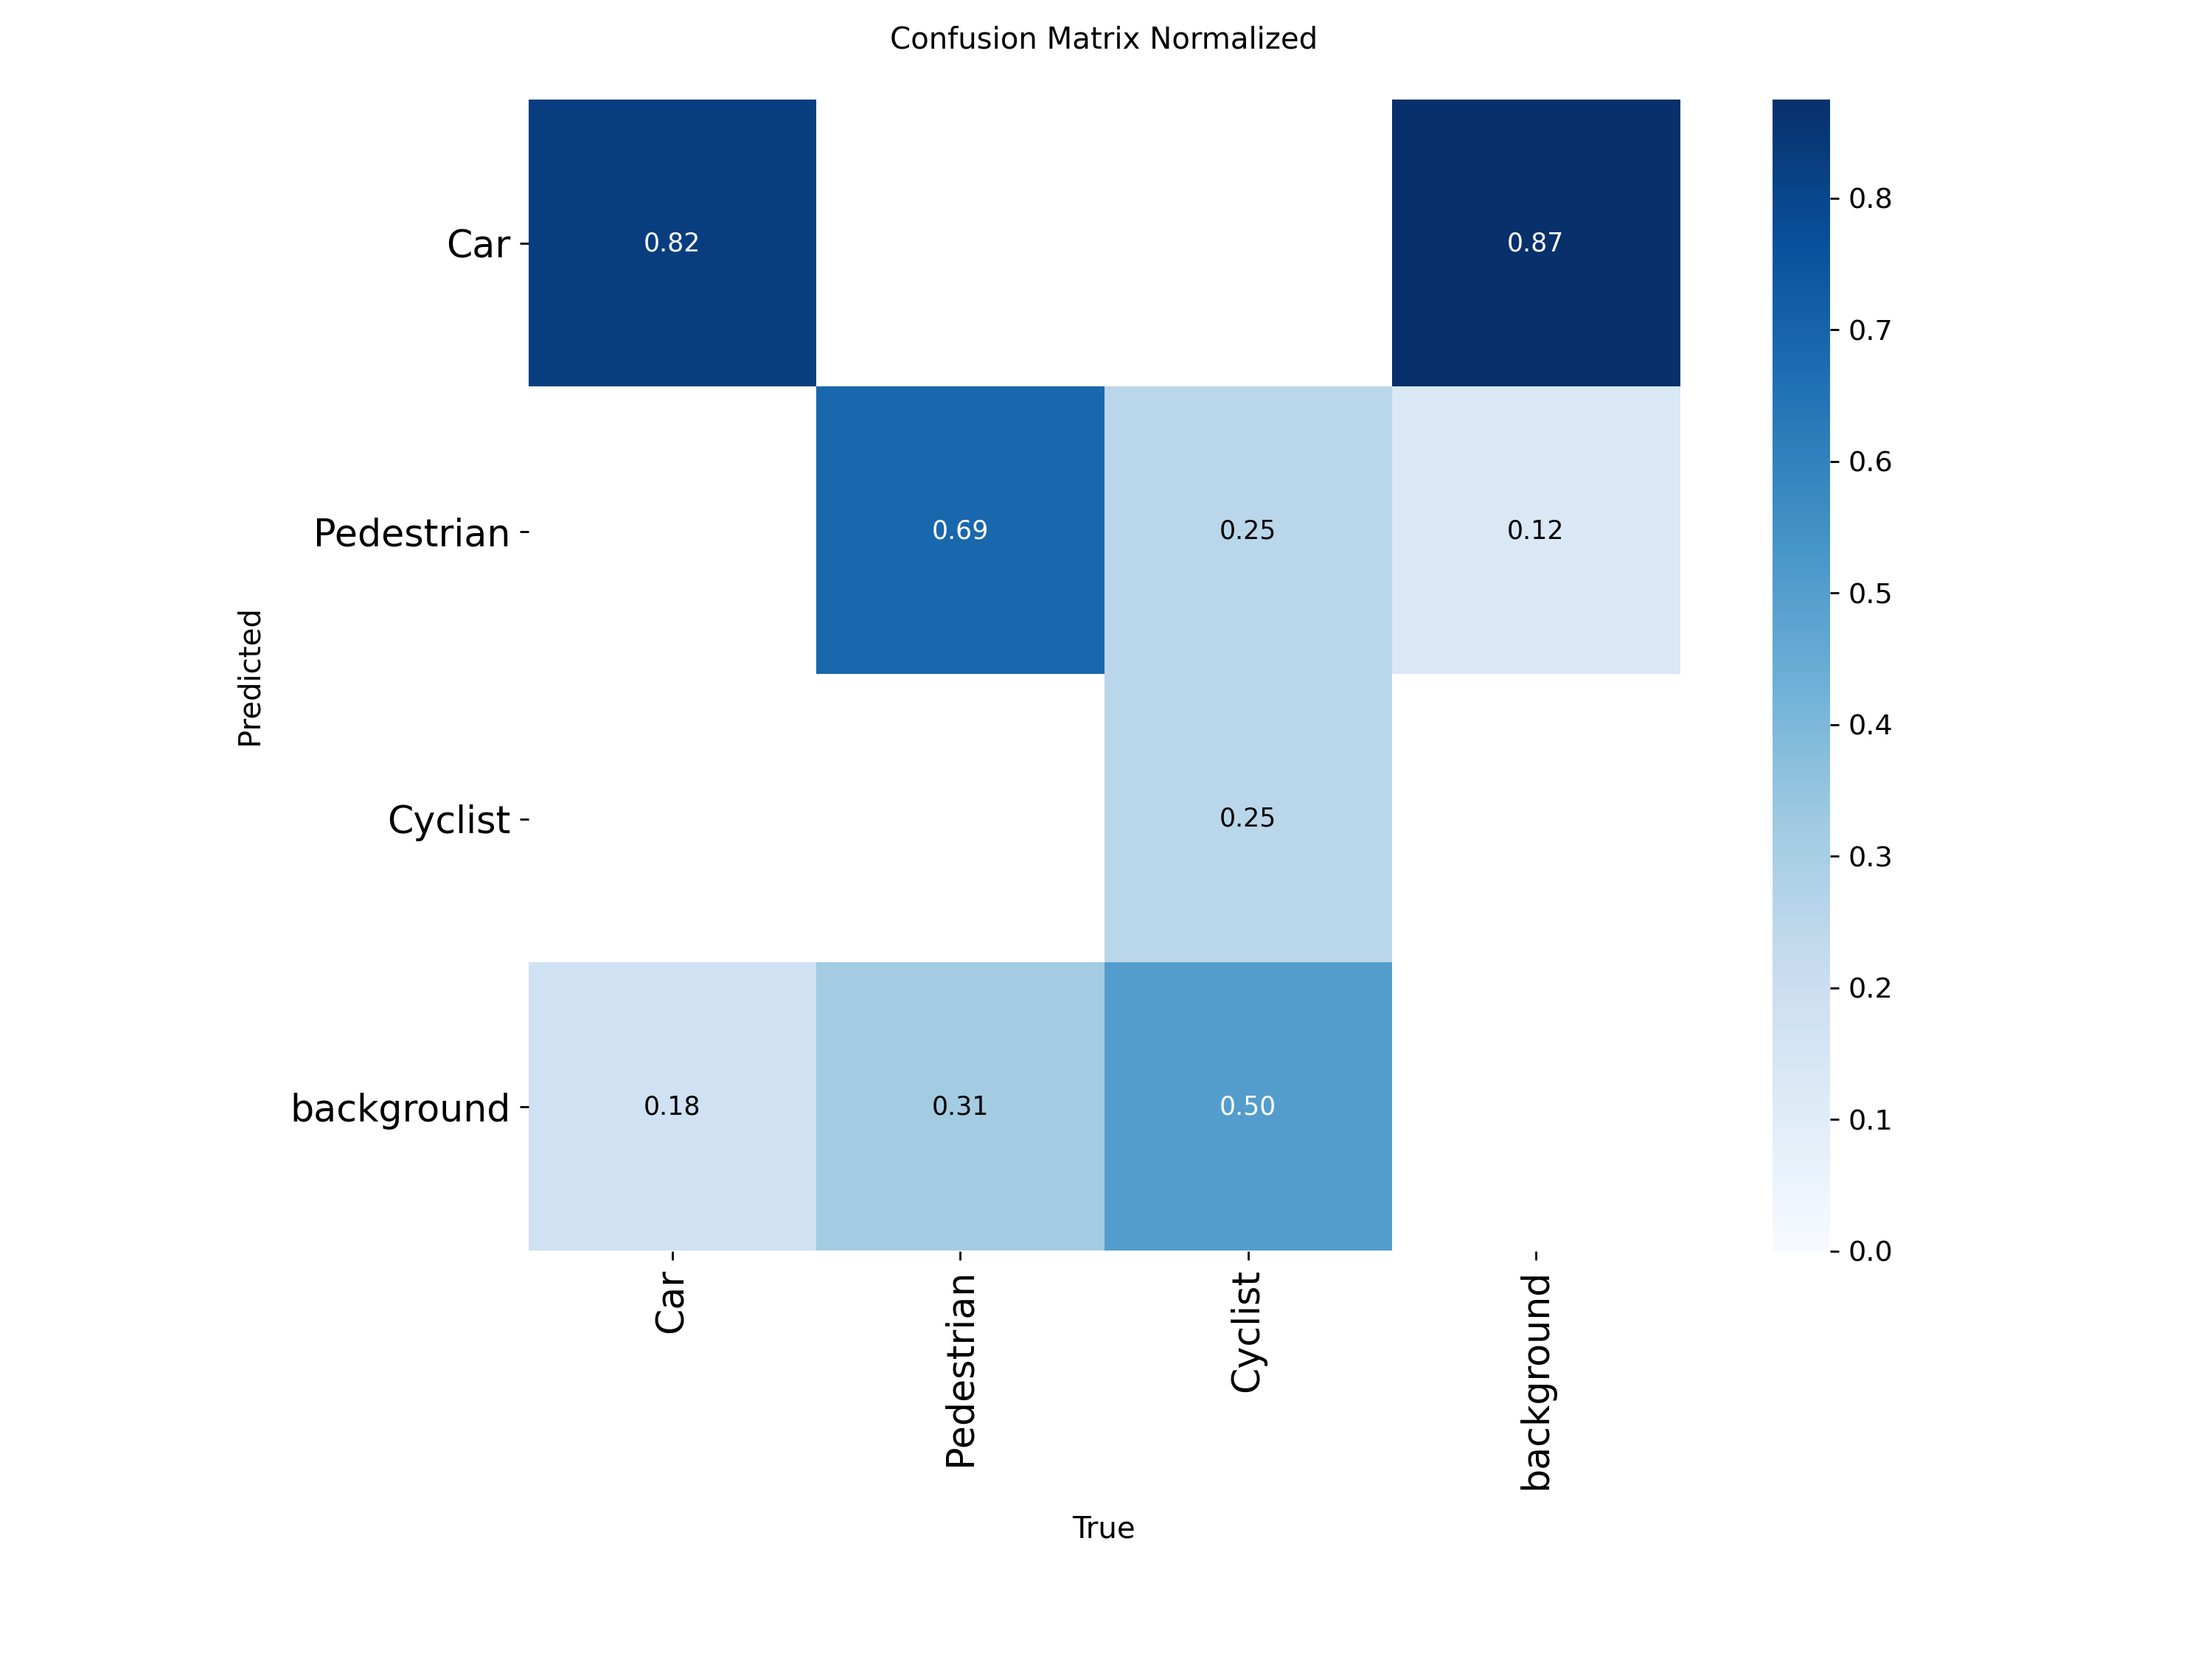

In [10]:
# ------ VISUALIZE CONFUSION MATRIX --------
#TO-DO: Add the code to visualize the confusion matrix
cm_path = os.path.join(RUN_DIR, "confusion_matrix.png")
cm_norm_path = os.path.join(RUN_DIR, "confusion_matrix_normalized.png")

print("confusion_matrix.png exists:", os.path.exists(cm_path))
print("confusion_matrix_normalized.png exists:", os.path.exists(cm_norm_path))

from IPython.display import Image, display

if os.path.exists(cm_path):
    print("Displaying confusion_matrix.png")
    display(Image(filename=cm_path))
else:
    print("confusion_matrix.png not found")

if os.path.exists(cm_norm_path):
    print("Displaying confusion_matrix_normalized.png")
    display(Image(filename=cm_norm_path))
else:
    print("confusion_matrix_normalized.png not found")


image 1/1 /content/datasets/kitti_subset/images/test/006301.png: 224x640 5 Cars, 56.3ms
Speed: 1.5ms preprocess, 56.3ms inference, 1.5ms postprocess per image at shape (1, 3, 224, 640)


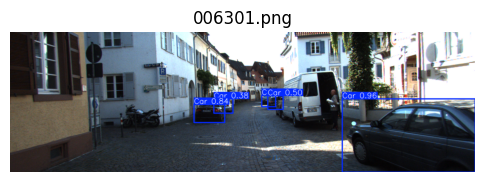


image 1/1 /content/datasets/kitti_subset/images/test/002731.png: 224x640 12 Cars, 12.9ms
Speed: 1.6ms preprocess, 12.9ms inference, 1.6ms postprocess per image at shape (1, 3, 224, 640)


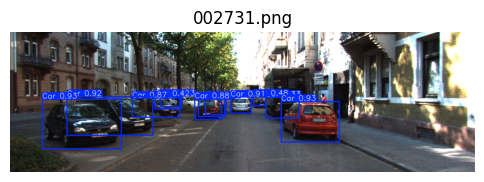


image 1/1 /content/datasets/kitti_subset/images/test/003814.png: 224x640 1 Car, 13.4ms
Speed: 1.7ms preprocess, 13.4ms inference, 2.2ms postprocess per image at shape (1, 3, 224, 640)


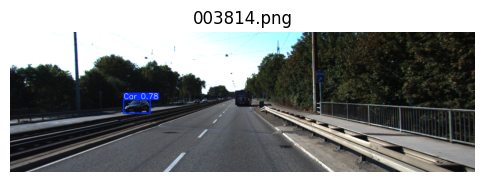


image 1/1 /content/datasets/kitti_subset/images/test/003446.png: 224x640 (no detections), 12.6ms
Speed: 2.1ms preprocess, 12.6ms inference, 0.8ms postprocess per image at shape (1, 3, 224, 640)


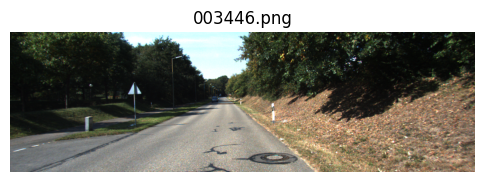


image 1/1 /content/datasets/kitti_subset/images/test/005355.png: 224x640 1 Car, 12.3ms
Speed: 1.9ms preprocess, 12.3ms inference, 1.9ms postprocess per image at shape (1, 3, 224, 640)


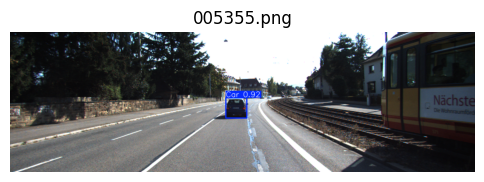

In [11]:
# -------- RUN INFERENCE AND PLOT SAMPLE OUTPUTS --------
#TO-DO: Add the code to run inference and visualize the outputs results

# 1. Load best trained model
BEST_MODEL_PATH = os.path.join(RUN_DIR, "weights", "best.pt")
model = YOLO(BEST_MODEL_PATH)

# 2. Get test images
test_images = sorted(glob.glob(os.path.join(TEST_IMG, "*.png")))

# 3. Randomly pick some images
sample_images = random.sample(test_images, 5)

# 4. Run inference and visualize
for img_path in sample_images:
    results = model(img_path)

    # Get plotted image (with bounding boxes)
    plotted_img = results[0].plot()

    # Convert BGR → RGB (for matplotlib)
    plotted_img = cv2.cvtColor(plotted_img, cv2.COLOR_BGR2RGB)

    # Show image
    plt.figure(figsize=(6,6))
    plt.imshow(plotted_img)
    plt.title(os.path.basename(img_path))
    plt.axis("off")
    plt.show()

## Question

Comment on the performance of the model based on the visualizations you made and discuss the inference speed versus performance for YOLO on the driving datasets. Do you think we can use YOLO online on autonomous cars?

## Ans
The model demonstrates reasonable performance on the KITTI subset, particularly for the "Car" class, where recall is relatively high. However, the confusion matrix reveals a large number of false positives, indicating low precision. Performance on "Pedestrian" and "Cyclist" is significantly weaker, with frequent misclassification and missed detections, especially for small or distant objects. These issues are mainly due to the small dataset size and the limited capacity of the YOLO11n model.

YOLO models are designed for real-time object detection and offer a good trade-off between speed and accuracy. Smaller models are fast but less accurate, while larger models improve accuracy at the cost of higher computational demand. This trade-off is critical in autonomous driving applications, where both speed and reliability are essential.

In its current form, the trained model is not suitable for deployment in autonomous vehicles due to its limited accuracy and robustness. However, YOLO-like architectures are widely used in real-world systems because of their efficiency. In practice, they are trained on large-scale datasets and integrated with additional modules such as tracking and sensor fusion.

Compared to Transformer-based models, which provide stronger global reasoning but are computationally expensive, YOLO remains a practical choice for real-time perception tasks in autonomous driving.